# CH 6 : Efficacité des procédures de comparaisons multiples selon le niveau de hasard

> **Idée centrale :** une procédure de comparaisons multiples peut être utile pour **classer** les règles candidates, mais dangereuse pour **estimer** leurs profits futurs lorsque le hasard domine.

Ce notebook transforme le concept en une démonstration pédagogique avec des exemples concrets, du code Python et des simulations orientées **trading**, **backtest** et **data-mining bias**.

L’objectif est de rendre visible une distinction fondamentale :

| Question | Ce que la MCP peut faire | Risque principal |
|---|---:|---|
| **Quelle règle semble la meilleure ?** | Assez utile, surtout avec beaucoup de données | Sélection parfois brouillée par le hasard |
| **Combien cette règle va-t-elle rapporter ?** | Très dangereux en trading | Surestimation systématique du profit futur |


## 1. Le problème en une phrase

Dans une **procédure de comparaisons multiples** (**MCP**), on teste plusieurs règles de trading, puis on sélectionne celle qui affiche la meilleure performance passée.

Le piège vient du fait que la meilleure performance observée mélange deux choses :

$$
P_{obs} = P_{pred} + H
$$

où :

- $P_{obs}$ est la **performance observée** en backtest.
- $P_{pred}$ est le **pouvoir prédictif réel** de la règle.
- $H$ est la contribution du **hasard**, positive ou négative.

> **Le classement peut être informatif, mais le chiffre du profit est contaminé par le hasard.**


## 2. Les deux promesses du minage de données

Le minage de données fait implicitement deux promesses :

| Promesse | Formulation | Validité en trading |
|---|---|---|
| **Promesse 1** | La meilleure règle observée est probablement la meilleure pour le futur | Partiellement vraie, surtout avec un grand échantillon |
| **Promesse 2** | Sa performance observée estime correctement sa performance future | Généralement fausse en environnement bruité |

La confusion du trader vient souvent du fait qu’il accepte la première promesse, puis applique automatiquement la deuxième.

C’est exactement là que le **data-mining bias** devient dangereux.


## 3. Analogie EBTA : le scanner d’or dans la boue

Imagine un scanner qui cherche la plus grosse pépite dans une masse de boue.

Le scanner peut assez bien dire :

> “Cette pépite semble être la plus grosse du tas.”

Mais il ne sait pas distinguer parfaitement le poids de l’or et le poids de la boue collée dessus.

En trading :

- **l’or** représente le **mérite réel** de la stratégie ;
- **la boue** représente le **hasard** ;
- le **backtest sélectionné** pèse souvent les deux en même temps.

Donc le trader croit avoir trouvé une pépite énorme, alors qu’une partie importante du poids disparaîtra en **out-of-sample**.


## 4. Setup de simulation

Nous allons simuler un univers de règles candidates.

Chaque règle possède un **mérite réel** inconnu du trader.

Ensuite, on observe une performance de backtest contaminée par du bruit :

$$
P_{obs,i} = P_{true,i} + \epsilon_i
$$

avec :

$$
\epsilon_i \sim \mathcal{{N}}(0, \sigma^2)
$$

Ici :

- $P_{true,i}$ est la performance future réelle moyenne de la règle $i$.
- $\epsilon_i$ est l’erreur due au hasard dans le backtest.
- $\sigma$ représente le niveau de hasard.

Plus $\sigma$ est élevé, plus le brouillard est épais.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

def simulate_mcp_once(n_rules=100, randomness=1.0, merit_spread=1.0):
    """
    Simule une procédure de comparaisons multiples.

    n_rules : nombre de règles candidates testées
    randomness : intensité du hasard dans le backtest
    merit_spread : dispersion du mérite réel entre les règles
    """
    true_performance = np.random.normal(loc=0.0, scale=merit_spread, size=n_rules)
    noise = np.random.normal(loc=0.0, scale=randomness, size=n_rules)
    observed_performance = true_performance + noise

    selected_idx = np.argmax(observed_performance)
    true_best_idx = np.argmax(true_performance)

    return {
        "selected_idx": selected_idx,
        "true_best_idx": true_best_idx,
        "selected_observed": observed_performance[selected_idx],
        "selected_true": true_performance[selected_idx],
        "true_best_true": true_performance[true_best_idx],
        "selection_correct": selected_idx == true_best_idx,
        "estimation_bias": observed_performance[selected_idx] - true_performance[selected_idx],
        "true_performance": true_performance,
        "observed_performance": observed_performance,
    }


## 5. Exemple visuel : faible hasard vs hasard élevé

Nous allons comparer deux environnements :

| Environnement | Signification |
|---|---|
| **Faible hasard** | Le mérite domine ; le classement observé reflète assez bien le mérite réel |
| **Hasard élevé** | Le bruit domine ; une règle médiocre peut sembler excellente par accident |

Dans un backtest réel, le trader ne voit que $P_{obs}$.

Il ne voit pas directement $P_{true}$.


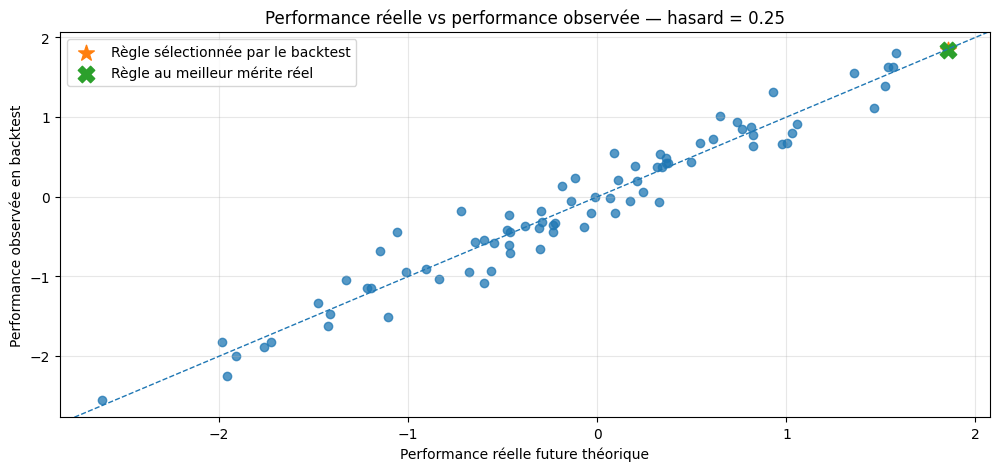

,hasard,règle_sélectionnée,vraie_meilleure_règle,performance_observée_sélectionnée,performance_réelle_sélectionnée,biais_d_estimation,sélection_correcte
0,0.25,31,31,1.846,1.852,-0.007,True


In [2]:
def plot_true_vs_observed(randomness, n_rules=80, merit_spread=1.0, seed=42):
    np.random.seed(seed)
    result = simulate_mcp_once(
        n_rules=n_rules,
        randomness=randomness,
        merit_spread=merit_spread,
    )

    df = pd.DataFrame({
        "rule": np.arange(n_rules),
        "true_performance": result["true_performance"],
        "observed_performance": result["observed_performance"],
    })

    selected = result["selected_idx"]
    true_best = result["true_best_idx"]

    plt.figure(figsize=(12, 5))
    plt.scatter(df["true_performance"], df["observed_performance"], alpha=0.75)
    plt.scatter(
        df.loc[selected, "true_performance"],
        df.loc[selected, "observed_performance"],
        s=140,
        marker="*",
        label="Règle sélectionnée par le backtest"
    )
    plt.scatter(
        df.loc[true_best, "true_performance"],
        df.loc[true_best, "observed_performance"],
        s=140,
        marker="X",
        label="Règle au meilleur mérite réel"
    )
    plt.axline((0, 0), slope=1, linestyle="--", linewidth=1)
    plt.title(f"Performance réelle vs performance observée — hasard = {randomness}")
    plt.xlabel("Performance réelle future théorique")
    plt.ylabel("Performance observée en backtest")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    summary = {
        "hasard": randomness,
        "règle_sélectionnée": selected,
        "vraie_meilleure_règle": true_best,
        "performance_observée_sélectionnée": round(result["selected_observed"], 3),
        "performance_réelle_sélectionnée": round(result["selected_true"], 3),
        "biais_d_estimation": round(result["estimation_bias"], 3),
        "sélection_correcte": result["selection_correct"],
    }

    return pd.DataFrame([summary])

low_randomness_summary = plot_true_vs_observed(randomness=0.25)
low_randomness_summary


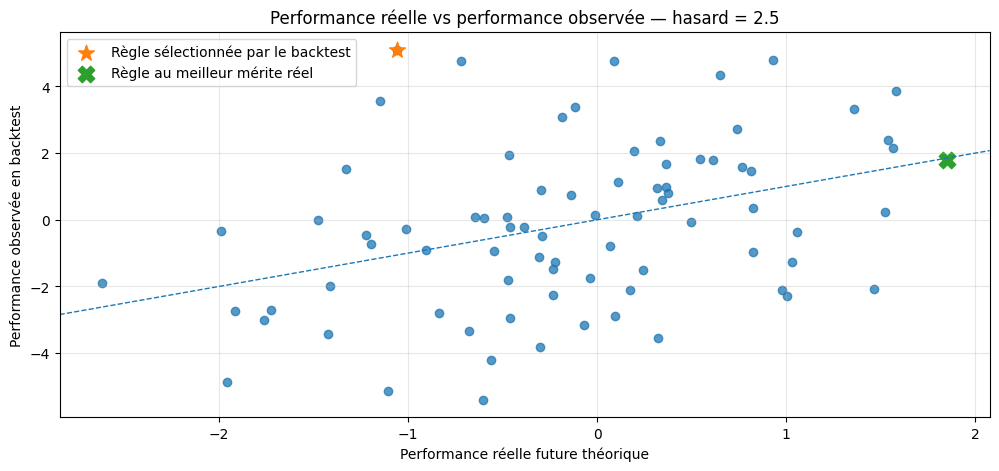

,hasard,règle_sélectionnée,vraie_meilleure_règle,performance_observée_sélectionnée,performance_réelle_sélectionnée,biais_d_estimation,sélection_correcte
0,2.5,33,31,5.1,-1.058,6.158,False


In [3]:
high_randomness_summary = plot_true_vs_observed(randomness=2.5)
high_randomness_summary


## 6. Lecture des graphiques

Dans le cas de **faible hasard**, les points restent proches de la diagonale.

Cela signifie que :

$$
P_{obs} \approx P_{true}
$$

Donc la performance passée donne une information relativement propre.

Dans le cas de **hasard élevé**, les points sont très dispersés.

Cela signifie que :

$$
P_{obs} = P_{true} + \text{beaucoup de bruit}
$$

La règle sélectionnée peut être celle qui a reçu le plus gros bonus de chance, pas nécessairement celle qui possède le meilleur pouvoir prédictif.


## 7. Monte Carlo : mesurer la réussite de sélection et le biais d’estimation

Maintenant, nous allons répéter l’expérience des milliers de fois.

Nous mesurerons deux choses :

| Mesure | Question |
|---|---|
| **Taux de sélection correcte** | Est-ce que la règle sélectionnée est vraiment la meilleure ? |
| **Biais d’estimation moyen** | De combien le backtest surestime-t-il la vraie performance de la règle sélectionnée ? |

La deuxième mesure est le cœur du problème EBTA.


In [4]:
def run_monte_carlo(
    n_simulations=5000,
    n_rules=100,
    randomness=1.0,
    merit_spread=1.0,
    seed=123,
):
    np.random.seed(seed)
    rows = []

    for _ in range(n_simulations):
        result = simulate_mcp_once(
            n_rules=n_rules,
            randomness=randomness,
            merit_spread=merit_spread,
        )
        rows.append({
            "selection_correct": result["selection_correct"],
            "selected_observed": result["selected_observed"],
            "selected_true": result["selected_true"],
            "estimation_bias": result["estimation_bias"],
            "true_best_true": result["true_best_true"],
        })

    return pd.DataFrame(rows)

randomness_levels = [0.1, 0.25, 0.5, 1.0, 1.5, 2.5, 4.0]

results = []
for r in randomness_levels:
    df_mc = run_monte_carlo(
        n_simulations=3000,
        n_rules=100,
        randomness=r,
        merit_spread=1.0,
        seed=123,
    )
    results.append({
        "niveau_de_hasard": r,
        "taux_selection_correcte": df_mc["selection_correct"].mean(),
        "performance_observee_moyenne_selectionnee": df_mc["selected_observed"].mean(),
        "performance_reelle_moyenne_selectionnee": df_mc["selected_true"].mean(),
        "biais_estimation_moyen": df_mc["estimation_bias"].mean(),
    })

summary_randomness = pd.DataFrame(results)
summary_randomness


,niveau_de_hasard,taux_selection_correcte,performance_observee_moyenne_selectionnee,performance_reelle_moyenne_selectionnee,biais_estimation_moyen
0,0.10,0.875333,2.522091,2.497819,0.024272
1,0.25,0.697333,2.585050,2.430492,0.154559
2,0.50,0.480667,2.807833,2.239986,0.567847
3,1.00,0.241000,3.549388,1.782330,1.767057
4,1.50,0.130667,4.526255,1.375725,3.150531
5,2.50,0.065667,6.768800,0.923057,5.845743
6,4.00,0.039667,10.368944,0.609383,9.759561


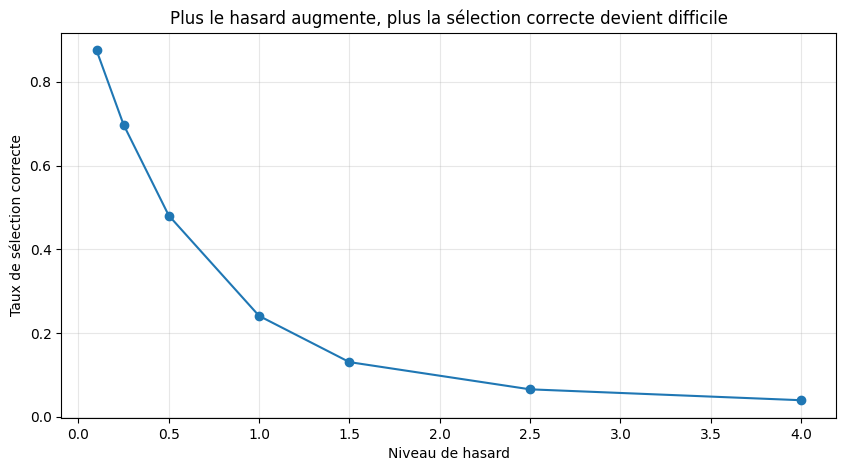

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(
    summary_randomness["niveau_de_hasard"],
    summary_randomness["taux_selection_correcte"],
    marker="o"
)
plt.title("Plus le hasard augmente, plus la sélection correcte devient difficile")
plt.xlabel("Niveau de hasard")
plt.ylabel("Taux de sélection correcte")
plt.grid(True, alpha=0.3)
plt.show()


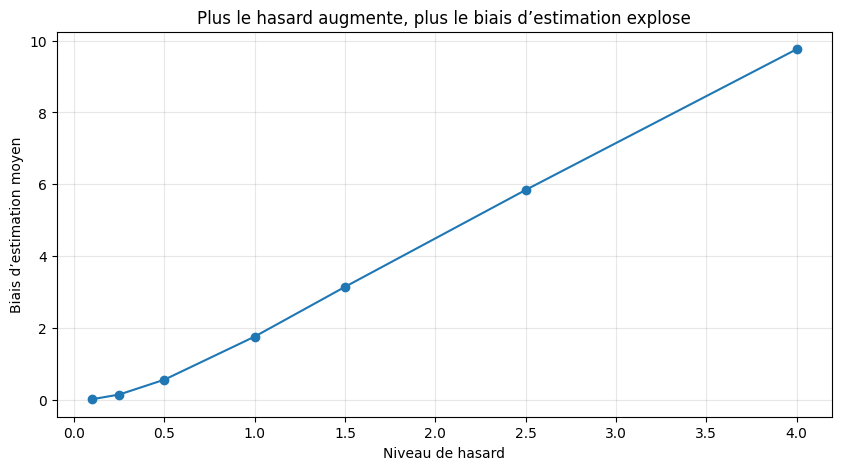

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(
    summary_randomness["niveau_de_hasard"],
    summary_randomness["biais_estimation_moyen"],
    marker="o"
)
plt.title("Plus le hasard augmente, plus le biais d’estimation explose")
plt.xlabel("Niveau de hasard")
plt.ylabel("Biais d’estimation moyen")
plt.grid(True, alpha=0.3)
plt.show()


## 8. Interprétation EBTA

Les simulations montrent deux phénomènes différents.

### 8.1. Le classement devient moins fiable

Quand le hasard augmente, le taux de sélection correcte baisse.

Ce n’est pas surprenant : le bruit peut faire passer une règle médiocre devant une règle supérieure.

### 8.2. L’estimation devient très biaisée

Le point le plus dangereux est le suivant :

> **La règle sélectionnée est précisément celle qui a bénéficié d’un hasard exceptionnellement favorable.**

Donc son backtest n’est pas une estimation neutre de sa valeur future.

Il est conditionné par le fait qu’elle a gagné le concours du passé.

Mathématiquement, le trader ne regarde pas une règle aléatoire.

Il regarde :

$$
\max(P_{obs,1}, P_{obs,2}, ..., P_{obs,M})
$$

Or le maximum d’un grand nombre de variables bruitées est naturellement gonflé.


## 9. Effet du nombre de règles testées

Plus on teste de règles, plus on augmente la probabilité de trouver un gagnant chanceux.

C’est l’un des mécanismes centraux du **data-mining bias**.

Nous allons garder le même niveau de hasard, mais augmenter le nombre de règles candidates.


In [7]:
n_rules_levels = [5, 10, 25, 50, 100, 250, 500, 1000]

results_rules = []
for n_rules in n_rules_levels:
    df_mc = run_monte_carlo(
        n_simulations=2500,
        n_rules=n_rules,
        randomness=1.5,
        merit_spread=1.0,
        seed=456,
    )
    results_rules.append({
        "nombre_de_regles_testees": n_rules,
        "taux_selection_correcte": df_mc["selection_correct"].mean(),
        "performance_observee_moyenne_selectionnee": df_mc["selected_observed"].mean(),
        "performance_reelle_moyenne_selectionnee": df_mc["selected_true"].mean(),
        "biais_estimation_moyen": df_mc["estimation_bias"].mean(),
    })

summary_rules = pd.DataFrame(results_rules)
summary_rules


,nombre_de_regles_testees,taux_selection_correcte,performance_observee_moyenne_selectionnee,performance_reelle_moyenne_selectionnee,biais_estimation_moyen
0,5,0.4280,2.124841,0.630522,1.494319
1,10,0.3140,2.795432,0.837714,1.957718
2,25,0.2240,3.556335,1.092346,2.463989
3,50,0.1508,4.054467,1.211943,2.842524
4,100,0.1324,4.540774,1.401976,3.138798
5,250,0.0940,5.106553,1.548559,3.557994
6,500,0.0876,5.482532,1.699280,3.783253
7,1000,0.0644,5.848581,1.785266,4.063315


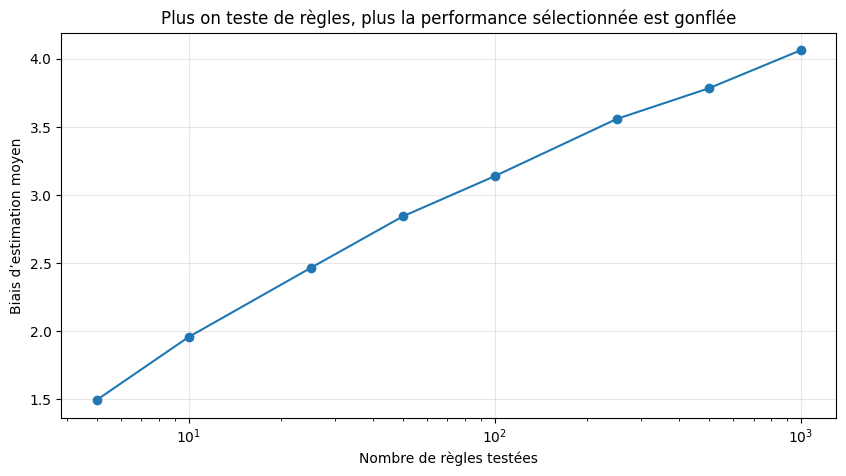

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(
    summary_rules["nombre_de_regles_testees"],
    summary_rules["biais_estimation_moyen"],
    marker="o"
)
plt.xscale("log")
plt.title("Plus on teste de règles, plus la performance sélectionnée est gonflée")
plt.xlabel("Nombre de règles testées")
plt.ylabel("Biais d’estimation moyen")
plt.grid(True, alpha=0.3)
plt.show()


## 10. Traduction trading : optimisation de paramètres

Dans le trading algorithmique, le nombre de règles testées peut exploser très vite.

Exemple :

| Paramètre | Valeurs testées |
|---|---:|
| Période de moyenne mobile rapide | 20 |
| Période de moyenne mobile lente | 30 |
| Stop-loss | 10 |
| Take-profit | 10 |
| Filtre horaire | 8 |

Le nombre total de combinaisons devient :

$$
20 \times 30 \times 10 \times 10 \times 8 = 480000
$$

Même avec des règles sans edge réel, certaines combinaisons afficheront un backtest impressionnant par hasard.


In [9]:
parameter_grid = {
    "ma_rapide": 20,
    "ma_lente": 30,
    "stop_loss": 10,
    "take_profit": 10,
    "filtre_horaire": 8,
}

total_combinations = np.prod(list(parameter_grid.values()))

pd.DataFrame({
    "paramètre": list(parameter_grid.keys()),
    "nombre_de_valeurs": list(parameter_grid.values()),
}).assign(
    combinaisons_totales=total_combinations
)


,paramètre,nombre_de_valeurs,combinaisons_totales
0,ma_rapide,20,480000
1,ma_lente,30,480000
2,stop_loss,10,480000
3,take_profit,10,480000
4,filtre_horaire,8,480000


## 11. Démonstration extrême : règles sans aucun edge

Maintenant, supposons que toutes les règles ont exactement le même mérite réel :

$$
P_{true,i} = 0
$$

Il n’existe donc aucune stratégie supérieure.

Et pourtant, si l’on teste beaucoup de règles, la meilleure performance observée sera souvent très positive.


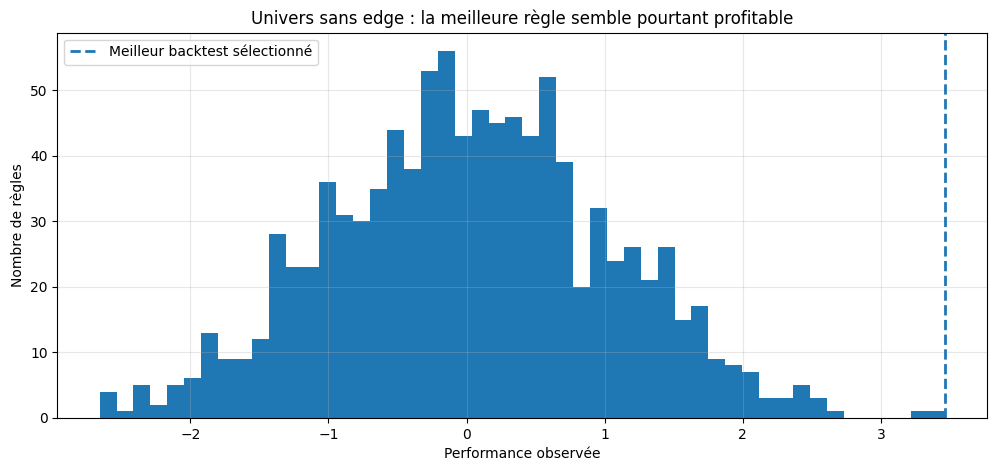

,nombre_de_regles,vraie_performance_de_toutes_les_regles,meilleure_performance_observee,biais_total
0,1000,0.0,3.465,3.465


In [10]:
def simulate_no_edge(n_rules=1000, randomness=1.0, seed=777):
    np.random.seed(seed)
    true_performance = np.zeros(n_rules)
    observed_performance = true_performance + np.random.normal(0, randomness, n_rules)
    selected_idx = np.argmax(observed_performance)

    df = pd.DataFrame({
        "rule": np.arange(n_rules),
        "true_performance": true_performance,
        "observed_performance": observed_performance,
    })

    return df, selected_idx

df_no_edge, selected_no_edge = simulate_no_edge(n_rules=1000, randomness=1.0)

plt.figure(figsize=(12, 5))
plt.hist(df_no_edge["observed_performance"], bins=50)
plt.axvline(
    df_no_edge.loc[selected_no_edge, "observed_performance"],
    linestyle="--",
    linewidth=2,
    label="Meilleur backtest sélectionné"
)
plt.title("Univers sans edge : la meilleure règle semble pourtant profitable")
plt.xlabel("Performance observée")
plt.ylabel("Nombre de règles")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame([{
    "nombre_de_regles": len(df_no_edge),
    "vraie_performance_de_toutes_les_regles": 0.0,
    "meilleure_performance_observee": round(df_no_edge.loc[selected_no_edge, "observed_performance"], 3),
    "biais_total": round(df_no_edge.loc[selected_no_edge, "observed_performance"], 3),
}])


## 12. La leçon psychologique pour le trader

Ce phénomène est difficile à accepter psychologiquement, car le backtest sélectionné est souvent magnifique.

Il donne une impression de compétence, de précision et de découverte.

Mais en réalité, une partie du résultat vient du processus de sélection lui-même.

> **Ce n’est pas parce qu’un backtest est beau qu’il est faux. Mais plus il vient d’une recherche large, plus il doit être traité comme suspect jusqu’à validation robuste.**


## 13. Checklist EBTA anti-illusion

| Question | Pourquoi c’est important |
|---|---|
| Combien de règles ai-je réellement testées ? | Plus $M$ est grand, plus le maximum est gonflé |
| Ai-je gardé une vraie période out-of-sample ? | Elle teste la survie du signal après sélection |
| Ai-je utilisé un walk-forward propre ? | Il limite l’auto-tromperie temporelle |
| Ai-je mesuré la dégradation attendue ? | Le profit futur doit être inférieur au backtest sélectionné |
| Ai-je comparé à des règles aléatoires ? | Cela révèle le niveau de chance possible |
| Ai-je assez de trades ? | Un petit échantillon amplifie le hasard |
| Ai-je pris en compte les coûts ? | Les coûts peuvent effacer un edge faible |


## 14. Règle pratique : faire confiance au classement, pas au rendement brut

Une bonne façon de résumer la section :

> **Utilise l’optimisation pour orienter la recherche, pas pour croire le chiffre final.**

Autrement dit :

- le minage peut aider à identifier une famille de règles intéressante ;
- il ne doit pas être utilisé seul pour prédire le profit futur ;
- la performance observée de la meilleure règle doit être **déflatée**, stressée et validée.

En EBTA, un backtest sélectionné n’est pas une preuve finale.

C’est un candidat à l’examen.


## 15. Mini-framework de validation après MCP

Voici un protocole simple après une optimisation :

| Étape | Objectif |
|---|---|
| 1. Sélectionner la meilleure règle in-sample | Identifier le candidat |
| 2. Déflater le rendement attendu | Corriger mentalement le biais d’optimisation |
| 3. Tester out-of-sample | Vérifier la survie hors de la zone minée |
| 4. Faire un walk-forward | Vérifier la stabilité dans le temps |
| 5. Tester la robustesse locale | Vérifier que les paramètres voisins fonctionnent aussi |
| 6. Comparer à du hasard | Mesurer si le résultat dépasse ce qu’un bruit peut produire |
| 7. Trader petit en live | Observer la transition backtest vers réel |


## 16. Eurêka final

> **Le minage de données est une boussole, pas une balance.**

Il peut indiquer quelle direction semble la plus prometteuse.

Mais il ne mesure pas proprement le poids réel du profit futur, surtout quand le marché est saturé de bruit.

Le trader professionnel ne demande pas seulement :

> “Quelle règle a gagné le backtest ?”

Il demande aussi :

> “Combien de cette victoire vient du mérite, et combien vient du hasard sélectionné ?”


## 17. Résumé opérationnel

- Une MCP compare plusieurs règles candidates.
- Le meilleur backtest est un maximum statistique.
- Un maximum statistique est naturellement biaisé vers le haut.
- Plus le hasard est élevé, plus le biais est grand.
- Plus le nombre de règles testées est élevé, plus le biais est grand.
- La sélection peut rester utile, mais l’estimation brute du profit est dangereuse.
- En trading, il faut toujours distinguer **classement** et **prévision de rendement**.


## Annexe — Source fournie par l’utilisateur

Le texte ci-dessous est la source originale collée par l’utilisateur pour générer ce notebook.


### **CH 6 : EFFICACITÉ DES PROCÉDURES DE COMPARAISONS MULTIPLES (MCP) SELON LE NIVEAU DE HASARD**

Cette section analyse la fiabilité du minage de données (en tant que procédure de comparaisons multiples) pour identifier les meilleures stratégies et estimer leurs gains futurs, en fonction de la part de hasard présente dans la discipline.

#### **(AJOUT) Idées clés :**
*   **Les deux promesses du minage :** Le minage de données promet (1) d'identifier la meilleure règle pour le futur et (2) de fournir une estimation fiable de son profit.
*   **Succès de la sélection :** White a prouvé mathématiquement que la règle affichant la meilleure performance passée est effectivement la plus susceptible d'être la meilleure à l'avenir.
*   **Échec de l'estimation :** En trading (hasard élevé), la performance observée n'est **pas** un indicateur fiable du montant des gains futurs car elle est positivement biaisée.
*   **Le brouillard du hasard :** Dans un environnement bruité, une règle médiocre peut battre une règle supérieure par pur "coup de bol", rendant la sélection moins précise.

#### **Référence :**
*The Effectiveness of Multiple Comparison Procedures under Differing Conditions of Randomness* (Pages 281–282) ; *MCP Efficacy in Low Randomness Situations* (Pages 282–283) ; *MCP Efficacy in High Randomness* (Pages 283–285).

#### **Citation Directe :**
« Many people presume that MCP delivers on two promises: (1) The candidate with the highest observed performance is most likely to perform the best in the future, and (2) the observed performance of the best-performing candidate is a reliable estimate of its future performance. It does deliver on the first promise. However, in the domain of TA rule back testing, it does not deliver on the second. » (Page 281-282).

---

#### **Vision Macro :**
L'enjeu est de comprendre l'asymétrie de confiance que l'on peut accorder au minage de données. David Aronson explique que si l'ordinateur est un excellent outil pour "classer" les idées (dire laquelle est la meilleure), il est un très mauvais outil pour "prédire" les profits (dire combien on va gagner). Le trader doit accepter que le minage de données remplit son rôle de boussole directionnelle, mais que le chiffre final du backtest est une illusion dopée par la chance qui s'évaporera inévitablement.

---

#### **Vision Micro :**

1.  **Efficacité en situation de faible hasard (Mérite dominant) :**
    *   **Mécanisme :** Lorsque le hasard a peu d'impact, les distributions de performance des candidats ne se chevauchent pas (Figure 6.14).
    *   **Exemple :** L'audition d'un violoniste. Un talent supérieur se traduira par une meilleure note, même si le musicien a un petit imprévu (hasard mineur). Ici, la performance observée prédit parfaitement le mérite réel.

2.  **Efficacité en situation de hasard élevé (Trading / AT) :**
    *   **Mécanisme :** Les marchés financiers sont saturés de bruit. Les distributions de performance des règles se chevauchent massivement (Figure 6.18).
    *   **Le risque de sélection :** Une règle sans aucune valeur prédictive (mérite = 0) peut afficher un profit spectaculaire par accident. Plus on teste de règles, plus il est probable qu'un "gagnant par chance" surpasse la règle réellement talentueuse.
    *   **Le paradoxe de White :** Bien que le hasard complique tout, White a prouvé que si l'échantillon de données est assez large, la probabilité que la meilleure règle soit identifiée tend vers 100 %. Le minage est donc "valide" pour choisir, mais "biaisé" pour estimer.

---

#### **(AJOUT) Résumé Simplifié :**
Le minage de données est comme un scanner qui cherche de l'or dans la boue. Il est très efficace pour te dire "cette pépite est la plus grosse du tas" (Promesse 1). Par contre, il est incapable de te dire son poids réel car il pèse aussi toute la boue qui est collée dessus (le hasard). En trading, la boue (le hasard) représente souvent 90 % du poids affiché. Si tu crois le chiffre du scanner, tu seras déçu une fois la pépite nettoyée.

---

#### **Actions Concrètes :**
*   **Faire confiance au classement, pas au rendement :** Utilisez les résultats de vos optimisations pour savoir *quelle* stratégie trader, mais divisez par deux (ou plus) vos attentes de gains réels.
*   **Exiger de grands échantillons :** La preuve de White ne fonctionne que si $N$ (le nombre de trades/jours) est très élevé. Ne minez jamais sur de petits historiques de données.
*   **Reconnaître le "Thin Fog" vs "Thick Fog" :** Si vous tradez des actifs très volatils (hasard élevé), attendez-vous à ce que le biais de minage soit colossal par rapport à des actifs plus stables.

---

#### **(AJOUT) À retenir absolument :**
*   Le minage de données identifie correctement la **meilleure règle** (Promesse 1 tenue).
*   Le minage de données **surestime systématiquement** le profit futur (Promesse 2 non tenue).
*   En trading, le hasard **domine** le mérite dans les résultats de backtest.
*   Plus le hasard est élevé, plus le **biais de minage** est grand.
*   L'échantillon doit être **large** pour que la logique du minage soit valide.

J'ai terminé l'analyse de l'efficacité du minage selon les conditions de hasard d'après le protocole EBTA.
